<a href="https://colab.research.google.com/github/Gabriellemga/Python_Data_Science_Alura/blob/main/Geopandas/Geopandas_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01-Introdução ao Geopandas

## Instalação da biblioteca Geopandas

In [179]:
#Instalando a biblioteca Geopandas
! pip install geopandas

In [180]:
#Importando a biblioteca as Geopandas
import geopandas as gpd

In [181]:
#Armazenando o shapefile em uma váriavel
rj = gpd.read_file('33MUE250GC_SIR.shp')

In [182]:
#Visualizando o tipo da variável rj
type(rj)

geopandas.geodataframe.GeoDataFrame

In [183]:
#Exibição dod dados da variável rj
rj

,ID,CD_GEOCODM,NM_MUNICIP,geometry
0,1468,3300100,ANGRA DOS REIS,"MULTIPOLYGON (((-44.33208 -23.02384, -44.33221..."
1,1469,3300159,APERIBÉ,"POLYGON ((-42.0895 -21.62893, -42.08912 -21.62..."
2,1470,3300209,ARARUAMA,"POLYGON ((-42.22526 -22.59253, -42.22521 -22.5..."
3,1471,3300225,AREAL,"POLYGON ((-43.16007 -22.20005, -43.16003 -22.1..."
4,1472,3300233,ARMAÇÃO DOS BÚZIOS,"MULTIPOLYGON (((-41.98427 -22.74458, -41.98296..."
...,...,...,...,...
87,1555,3306008,TRÊS RIOS,"POLYGON ((-43.13666 -22.10933, -43.13182 -22.1..."
88,1556,3306107,VALENÇA,"POLYGON ((-43.8212 -22.08844, -43.82101 -22.08..."
89,1557,3306156,VARRE-SAI,"POLYGON ((-41.82695 -20.84164, -41.82686 -20.8..."
90,1558,3306206,VASSOURAS,"POLYGON ((-43.61208 -22.30841, -43.61113 -22.3..."


<Axes: >

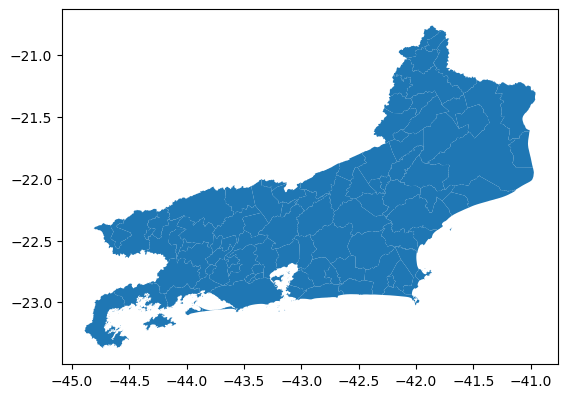

In [184]:
#Plotagem do mapa do Rio de Janeiro
rj.plot()

<Axes: >

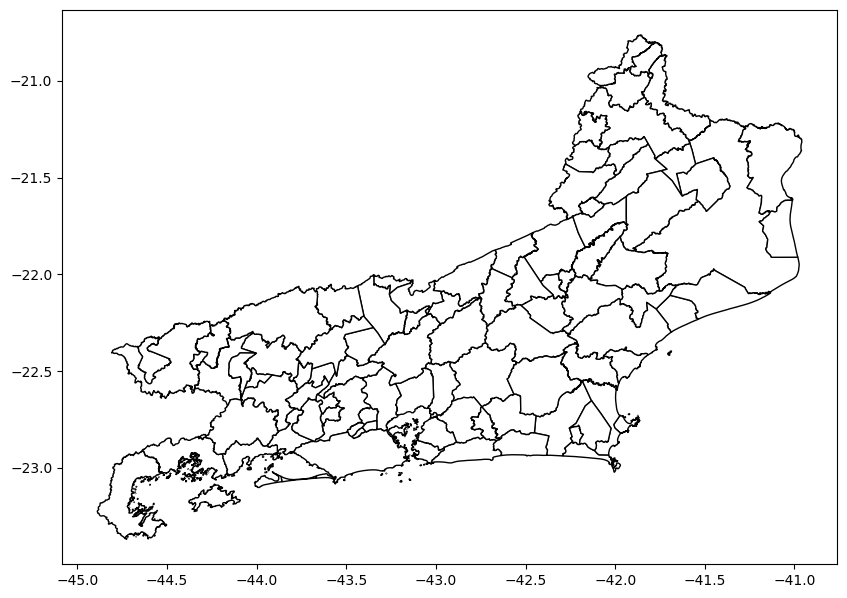

In [185]:
rj.plot(color = 'white', edgecolor = 'black', figsize = (10,8))

## Entendendo Polygon, Point e outros shapes

In [186]:
#Importação de geometrias básicas do Shapely
from shapely.geometry import Point, LineString, Polygon, MultiPolygon

<Axes: >

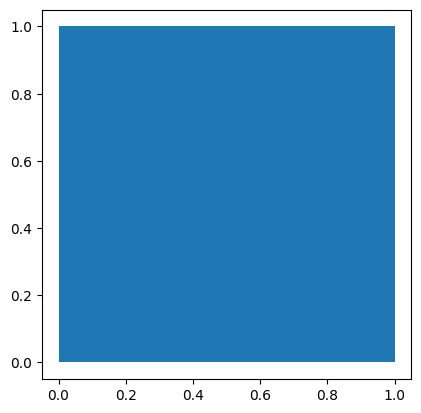

In [187]:
# Plotagem de um quadrado
p1 = Polygon([(0, 0),(1, 0),(1, 1),(0, 1)])

g = gpd.GeoSeries(p1)
g.plot()

<Axes: >

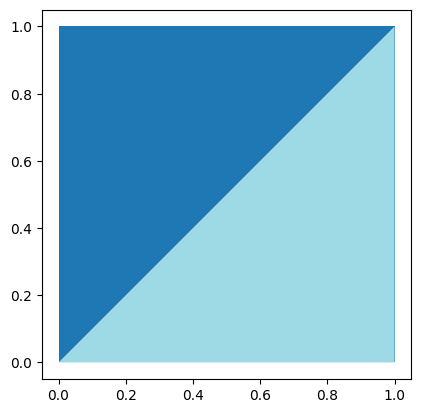

In [188]:
p1 = Polygon([(0, 0),(1, 0),(1, 1),(0, 1)])
p2 = Polygon([(0, 0),(1, 0),(1, 1)])
g = gpd.GeoSeries([p1, p2])
g.plot(cmap="tab20")

<Axes: >

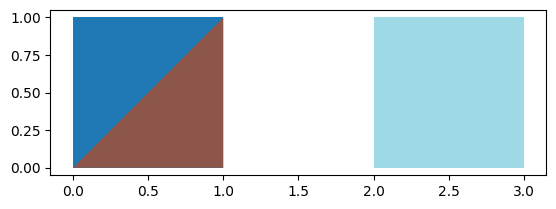

In [189]:
p1 = Polygon([(0, 0),(1, 0),(1, 1),(0, 1)])
p2 = Polygon([(0, 0),(1, 0),(1, 1)])

p3 = Polygon([(2, 0),(3, 0),(3, 1),(2, 1)])
g = gpd.GeoSeries([p1, p2, p3])
g.plot(cmap="tab20")

<Axes: >

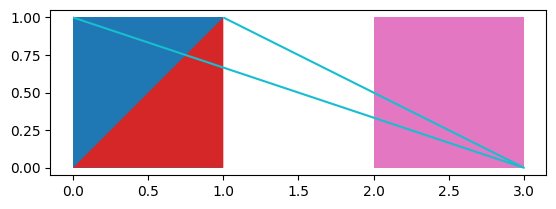

In [190]:
p1 = Polygon([(0, 0),(1, 0),(1, 1),(0, 1)])
p2 = Polygon([(0, 0),(1, 0),(1, 1)])

p3 = Polygon([(2, 0),(3, 0),(3, 1),(2, 1)])

p4 = LineString([(0,1),(3,0),(1,1)])

g = gpd.GeoSeries([p1, p2, p3, p4])
g.plot(cmap="tab10")

<Axes: >

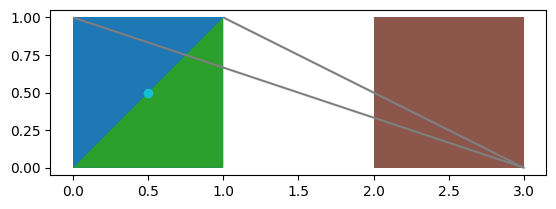

In [191]:
p1 = Polygon([(0, 0),(1, 0),(1, 1),(0, 1)])
p2 = Polygon([(0, 0),(1, 0),(1, 1)])

p3 = Polygon([(2, 0),(3, 0),(3, 1),(2, 1)])

p4 = LineString([(0,1),(3,0),(1,1)])

p5 = Point(0.5, 0.5)

g = gpd.GeoSeries([p1, p2, p3, p4, p5])
g.plot(cmap="tab10")

<Axes: >

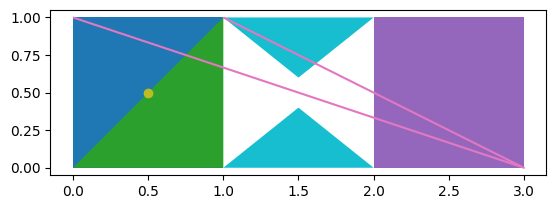

In [192]:
p1 = Polygon([(0, 0),(1, 0),(1, 1),(0, 1)])
p2 = Polygon([(0, 0),(1, 0),(1, 1)])

p3 = Polygon([(2, 0),(3, 0),(3, 1),(2, 1)])

p4 = LineString([(0,1),(3,0),(1,1)])

p5 = Point(0.5, 0.5)

p6 = Polygon([(1, 0),(1.5, 0.4),(2, 0)])
p7 = Polygon([(1, 1),(1.5, 0.6),(2, 1)])

p8 = MultiPolygon([p6, p7])

g = gpd.GeoSeries([p1, p2, p3, p4, p5, p8])
g.plot(cmap="tab10")

# 02- Dataframe ao GeoPandas

## Criando shapefiles

<Axes: >

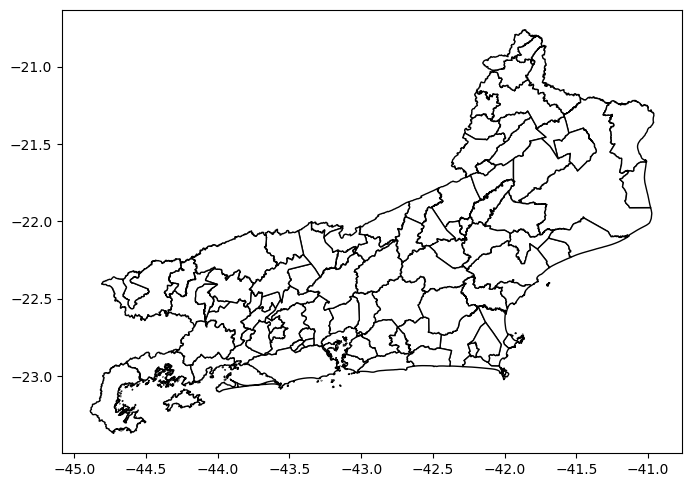

In [193]:
rj.plot(color = 'white', edgecolor = 'black', figsize = (8,8))

In [194]:
#Selecionando o municipio do Rio de Janeiro
rj_rj = rj[rj['NM_MUNICIP'] == 'RIO DE JANEIRO']
rj_rj

,ID,CD_GEOCODM,NM_MUNICIP,geometry
67,1535,3304557,RIO DE JANEIRO,"MULTIPOLYGON (((-43.12376 -22.80712, -43.1238 ..."


<Axes: >

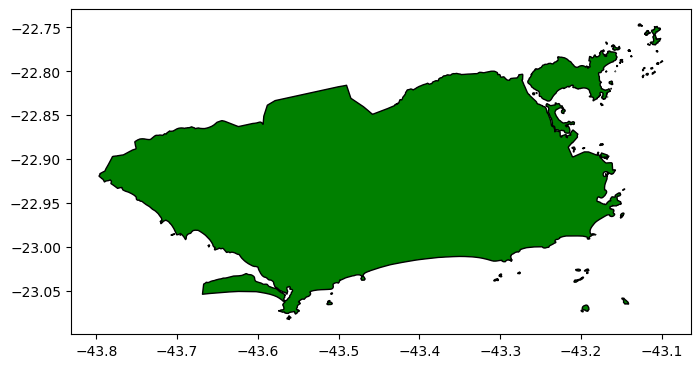

In [195]:
rj_rj.plot(color = 'green', edgecolor = 'black', figsize = (8,8))

In [196]:
#Salvando o shapefile
rj_rj.to_file('RJ-MUN.shp')

## Transformando DataFrame em GeoDataframe

In [197]:
#Importando a biblioteca Pandas
import pandas as pd

In [198]:
#Lendo arquivo txt
dados = pd.read_table('dados.txt')
dados

,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor
0,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000
1,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000
2,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000
3,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000
4,85,Gávea,Rio de Janeiro,Rua Marquês de São Vicente,RJ,-14.235004,-51.925280,2,1,2,Apartamento,Venda,1800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,48,Campo Grande,Rio de Janeiro,Rua Josué de Barros,RJ,-22.878349,-43.550762,2,0,1,Apartamento,Venda,170000
4996,75,Recreio dos Bandeirantes,Rio de Janeiro,Rua Le Corbusier,RJ,-23.024717,-43.487285,3,1,1,Apartamento,Venda,550000
4997,32,Jardim Botânico,Rio de Janeiro,Rua Getúlio das Neves,RJ,-22.959433,-43.206180,1,0,0,Apartamento,Venda,580000
4998,85,Grajaú,Rio de Janeiro,Rua Jerônimo de Lemos,RJ,-22.918773,-43.260492,3,0,0,Apartamento,Venda,325000


In [199]:
from shapely.geometry import Point

In [200]:
#Armazenando as coordenadas
geometry = [Point(xy) for xy in zip(dados.Longitude, dados.Latitude)]

In [201]:
# Criando o GeoDataFrame
#crs = {'proj': 'latlong', 'ellps': 'WGS84', 'datum': 'WGS84', 'no_defs': True}

geo_dados = gpd.GeoDataFrame(dados, crs = 4326, geometry = geometry)
geo_dados

,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry
0,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000,POINT (-43.46295 -23.01646)
1,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000,POINT (-43.33691 -22.9432)
2,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000,POINT (-43.30052 -22.87385)
3,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000,POINT (-43.4127 -22.98479)
4,85,Gávea,Rio de Janeiro,Rua Marquês de São Vicente,RJ,-14.235004,-51.925280,2,1,2,Apartamento,Venda,1800000,POINT (-51.92528 -14.235)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,48,Campo Grande,Rio de Janeiro,Rua Josué de Barros,RJ,-22.878349,-43.550762,2,0,1,Apartamento,Venda,170000,POINT (-43.55076 -22.87835)
4996,75,Recreio dos Bandeirantes,Rio de Janeiro,Rua Le Corbusier,RJ,-23.024717,-43.487285,3,1,1,Apartamento,Venda,550000,POINT (-43.48729 -23.02472)
4997,32,Jardim Botânico,Rio de Janeiro,Rua Getúlio das Neves,RJ,-22.959433,-43.206180,1,0,0,Apartamento,Venda,580000,POINT (-43.20618 -22.95943)
4998,85,Grajaú,Rio de Janeiro,Rua Jerônimo de Lemos,RJ,-22.918773,-43.260492,3,0,0,Apartamento,Venda,325000,POINT (-43.26049 -22.91877)


In [202]:
#Salvando o GeodataFrame
geo_dados.to_file('Dataset.shp')

# 03-Sistema de coordenadas

## Modificando O CRS dos arquivos do projeto

### Referências

https://www.lapig.iesa.ufg.br/lapig/cursos_online/gvsig/a_projeo_utm_no_brasil.html

http://www.spatialreference.org/

In [203]:
rj_rj = gpd.read_file('RJ-MUN.shp')

In [204]:
geo_dados = gpd.read_file('Dataset.shp')

In [205]:
# Verificando o CRS do shapefile rj_rj
rj_rj.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [206]:
#Verificando o CRS do shapefile geodados
geo_dados.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [207]:
# Modificando o CRS
#rj_rj = rj_rj.to_crs('+proj=utm +zone=23 +south +ellps=GRS80 +units=km +no_defs +type=crs')
rj_rj = rj_rj.to_crs(epsg = 31983)

In [208]:
# Modificando o CRS
geo_dados = geo_dados.to_crs(epsg=31983)

In [209]:
# Conferindo o CRS
rj_rj.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - between 48°W and 42°W, northern and southern hemispheres, onshore and offshore.
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [210]:
geo_dados.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - between 48°W and 42°W, northern and southern hemispheres, onshore and offshore.
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [211]:
#Salvando os arquivos com os CRS modificados

rj_rj.to_file('RJ-MUN-UTM.shp')
geo_dados.to_file('Dataset-UTM.shp')

In [212]:
#Lendo os arquivos em UTM
rj_rj_utm = gpd.read_file('RJ-MUN-UTM.shp')
geo_dados_utm = gpd.read_file('Dataset-UTM.shp')

In [213]:
rj_rj_utm.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - between 48°W and 42°W, northern and southern hemispheres, onshore and offshore.
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [214]:
geo_dados_utm.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - between 48°W and 42°W, northern and southern hemispheres, onshore and offshore.
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

# 04-Filtando imóveis por região

## Selecionando pontos dentro de uma região

<Axes: >

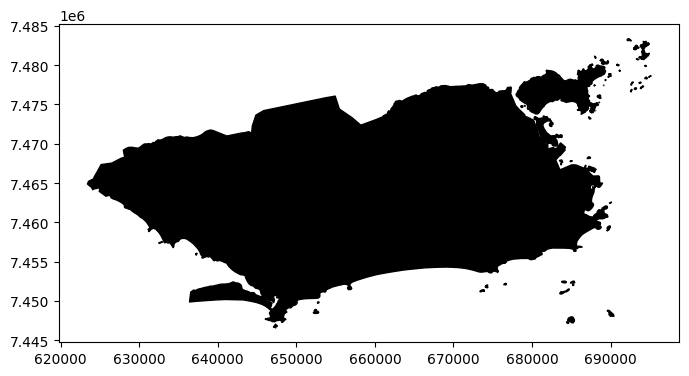

In [215]:
# Criando a base
base = rj_rj_utm.plot(color = 'black', edgecolor = 'black', figsize = (8,8))
base

<Axes: >

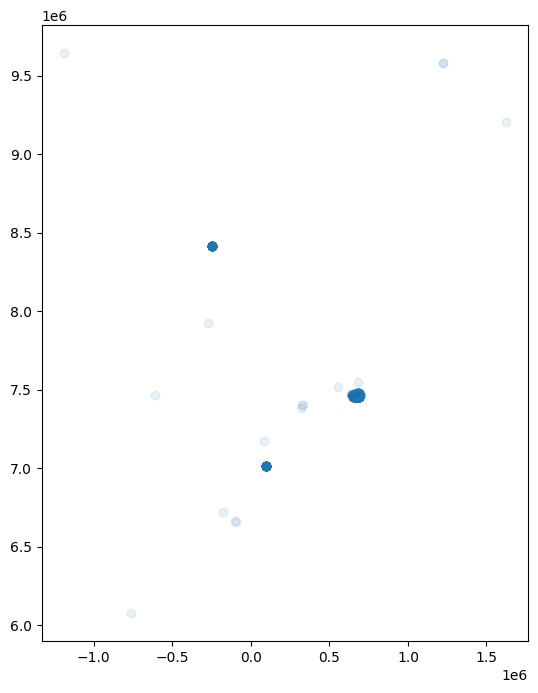

In [216]:
#Plotando mapas com camadas
base = rj_rj_utm.plot(color = 'white', edgecolor = 'black', figsize = (15,8))
geo_dados_utm.plot(ax = base, figsize = (15,8), alpha = 0.1)

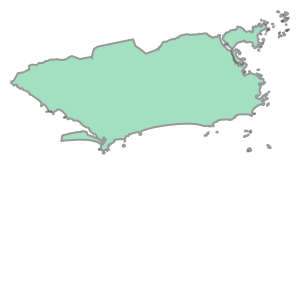

In [231]:
rj_rj_utm.iloc[0].geometry

In [232]:
geo_dados_rj = geo_dados_utm[geo_dados_utm['geometry'].within(rj_rj_utm.iloc[0].geometry)]

<Axes: >

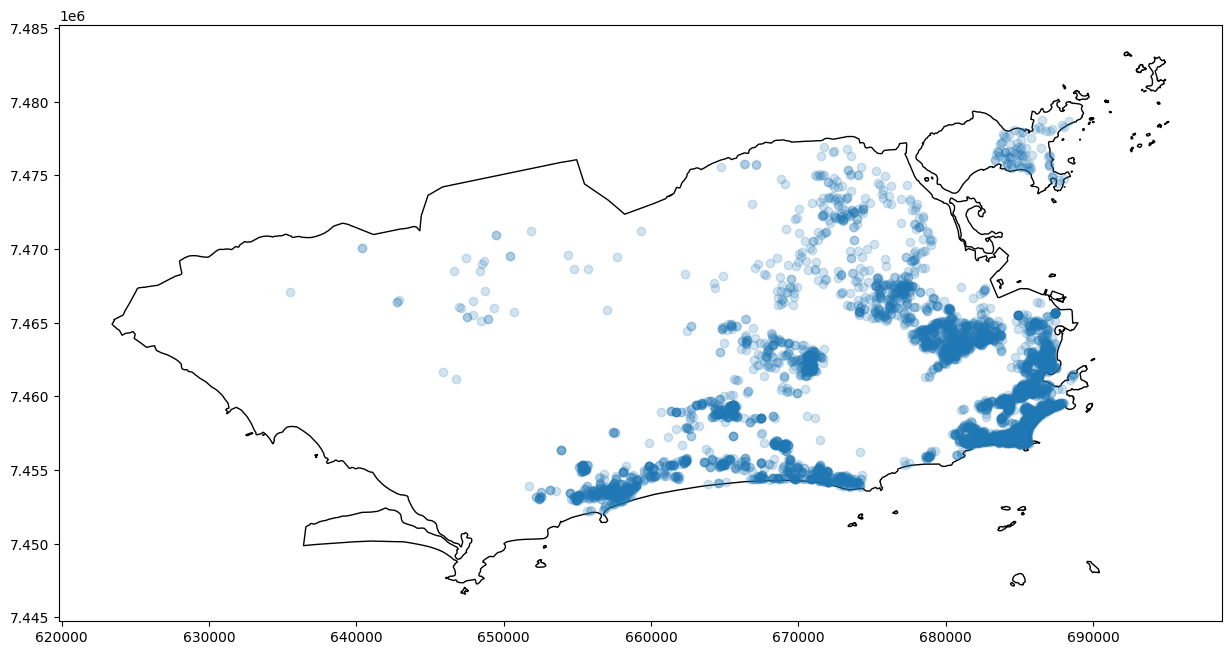

In [233]:
base = rj_rj_utm.plot(color='white', edgecolor='black', figsize=(15,8))
geo_dados_rj.plot(ax=base, figsize=(15,8), alpha=0.2)

In [234]:
geo_dados_rj.to_file('DATASET.shp')

# 05- Calculando distâncias

In [239]:
#Lendo o geojson das Estações de metrô
metro = gpd.read_file('Estações_Metrô.geojson')
metro.head()

,OBJECTID,Cod,Nome,Flg_ATM,Flg_Bicicletario,Flg_Elevador,Flg_Linha1,Flg_Linha2,Obs,Flg_Ativa,...,Integra_Trem,Integra_Onibus,Integra_BRT,Corredor,Integra_VLT,Onibus,Flg_Metro_Superficie,Metro_Superficie,Data_Inauguracao,geometry
0,1,1,Pavuna,1,1.0,1.0,0,1,None,1,...,1,0,0,None,0,None,0,None,1998,POINT (-43.36485 -22.80662)
1,2,2,Engenheiro Rubens Paiva,1,1.0,1.0,0,1,None,1,...,0,0,0,None,0,None,0,None,1998,POINT (-43.35845 -22.81627)
2,3,3,Acari / Fazenda Botafogo,0,0.0,0.0,0,1,None,1,...,0,0,0,None,0,None,0,None,1998,POINT (-43.34964 -22.82452)
3,4,4,Coelho Neto,1,0.0,0.0,0,1,None,1,...,0,0,0,None,0,None,0,None,1998,POINT (-43.34326 -22.83148)
4,5,5,Colégio,1,1.0,0.0,0,1,None,1,...,0,0,0,None,0,None,0,None,1998,POINT (-43.33386 -22.84269)


In [240]:
# Verificando o CRS
metro.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [241]:
#Modificando o CRS
metro = metro.to_crs(epsg = 31983)

<Axes: >

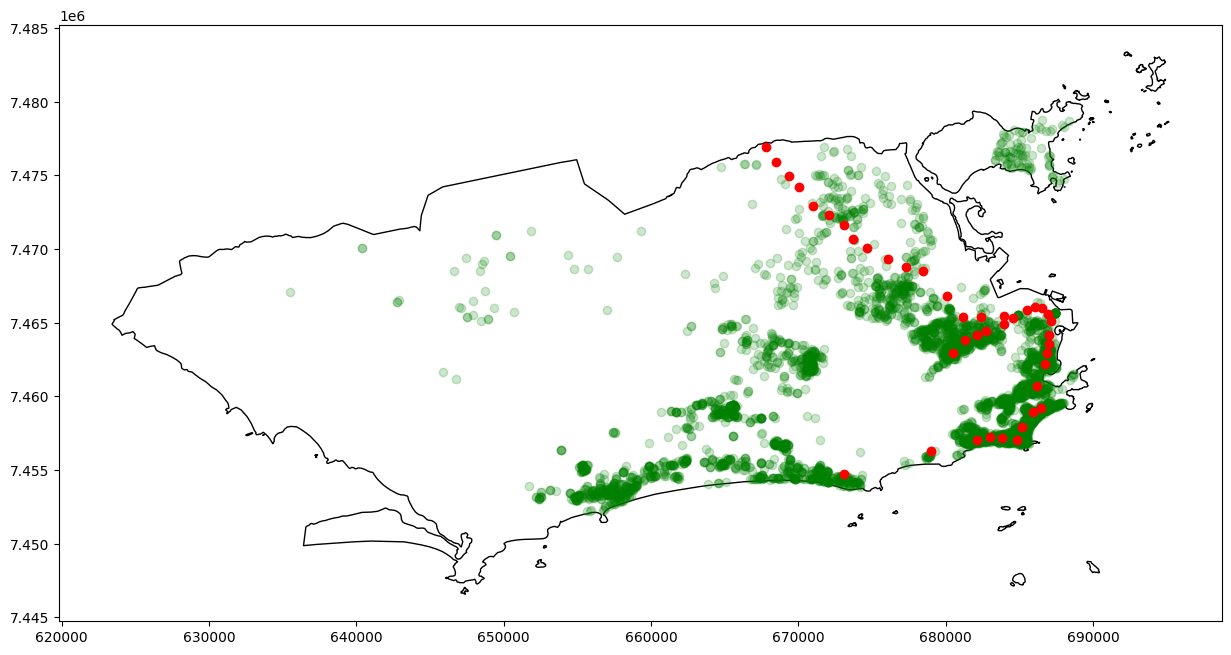

In [245]:
#Plotando os dados das estações de metrô
base = rj_rj_utm.plot(color='white', edgecolor='black', figsize=(15,8))
geo_dados_rj.plot(ax=base,color = 'green', figsize=(15,8), alpha=0.2)
metro.plot(ax=base, color = 'red', figsize=(15,8))

In [250]:
# Calculo da distâncias em linha reta

#Estação de metrô mais próxima do primeiro registro do conjunto geo_dados
distances = metro.distance(geo_dados_rj.iloc[0].geometry)
distances

,0
0,25321.516224
1,24623.350028
2,24224.237382
3,23881.157847
4,23357.574694
5,23523.396149
6,23658.163169
7,23401.047741
8,23644.084286
9,24209.373205


In [251]:
# Menor distância em Km
distances.min()/1000

15.622938824995046

In [252]:
# Calculo da distâncias minimas
geo_dados_rj['Dist_Metro'] = geo_dados_rj['geometry'].apply(lambda x: (metro.distance(x).min())/1000)
geo_dados_rj

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry,Dist_Metro
0,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000,POINT (657513.707 7453832.425),15.622939
1,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000,POINT (670523.903 7461803.088),7.530741
2,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000,POINT (674345.004 7469439.743),0.736973
3,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000,POINT (662701.378 7457284.071),10.718039
5,260,Recreio dos Bandeirantes,Rio de Janeiro,Rua Desembargador Paulo Alonso,RJ,-23.018927,-43.477505,3,1,2,Apartamento,Venda,1160000,POINT (656018.715 7453574.299),17.131159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,48,Campo Grande,Rio de Janeiro,Rua Josué de Barros,RJ,-22.878349,-43.550762,2,0,1,Apartamento,Venda,170000,POINT (648663.999 7469215.8),20.667831
4996,75,Recreio dos Bandeirantes,Rio de Janeiro,Rua Le Corbusier,RJ,-23.024717,-43.487285,3,1,1,Apartamento,Venda,550000,POINT (655009.667 7452943.597),18.189134
4997,32,Jardim Botânico,Rio de Janeiro,Rua Getúlio das Neves,RJ,-22.959433,-43.206180,1,0,0,Apartamento,Venda,580000,POINT (683909.38 7459847.754),2.180300
4998,85,Grajaú,Rio de Janeiro,Rua Jerônimo de Lemos,RJ,-22.918773,-43.260492,3,0,0,Apartamento,Venda,325000,POINT (678393.129 7464417.213),2.558248


In [262]:
# Correlação entre as variáveis
geo_dados_rj.corr(numeric_only = True)

,Area,Latitude,Longitude,Quartos,Suites,Vagas,Valor,Dist_Metro
Area,1.000000,-0.289299,0.029982,0.681112,0.585817,0.594699,0.724397,-0.036671
Latitude,-0.289299,1.000000,0.292822,-0.225226,-0.346480,-0.274707,-0.299038,-0.217864
Longitude,0.029982,0.292822,1.000000,-0.016882,-0.221548,-0.283960,0.191868,-0.874788
Quartos,0.681112,-0.225226,-0.016882,1.000000,0.529611,0.520499,0.481216,0.021794
Suites,0.585817,-0.346480,-0.221548,0.529611,1.000000,0.621140,0.464075,0.188521
Vagas,0.594699,-0.274707,-0.283960,0.520499,0.621140,1.000000,0.456596,0.215787
Valor,0.724397,-0.299038,0.191868,0.481216,0.464075,0.456596,1.000000,-0.195641
Dist_Metro,-0.036671,-0.217864,-0.874788,0.021794,0.188521,0.215787,-0.195641,1.000000


In [260]:
coef = geo_dados_rj['Valor'].corr(geo_dados_rj['Dist_Metro'])
coef

np.float64(-0.19564083161686902)

In [263]:
geo_dados_rj.to_file('DATASET.shp')

# 05- Agrgando outras localizações

In [266]:
# Dados metrô
metro.head()

,OBJECTID,Cod,Nome,Flg_ATM,Flg_Bicicletario,Flg_Elevador,Flg_Linha1,Flg_Linha2,Obs,Flg_Ativa,...,Integra_Trem,Integra_Onibus,Integra_BRT,Corredor,Integra_VLT,Onibus,Flg_Metro_Superficie,Metro_Superficie,Data_Inauguracao,geometry
0,1,1,Pavuna,1,1.0,1.0,0,1,None,1,...,1,0,0,None,0,None,0,None,1998,POINT (667826.659 7476958.649)
1,2,2,Engenheiro Rubens Paiva,1,1.0,1.0,0,1,None,1,...,0,0,0,None,0,None,0,None,1998,POINT (668471.381 7475883.247)
2,3,3,Acari / Fazenda Botafogo,0,0.0,0.0,0,1,None,1,...,0,0,0,None,0,None,0,None,1998,POINT (669365.484 7474959.4)
3,4,4,Coelho Neto,1,0.0,0.0,0,1,None,1,...,0,0,0,None,0,None,0,None,1998,POINT (670012.314 7474181.737)
4,5,5,Colégio,1,1.0,0.0,0,1,None,1,...,0,0,0,None,0,None,0,None,1998,POINT (670962.645 7472929.607)


In [267]:
metro.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - between 48°W and 42°W, northern and southern hemispheres, onshore and offshore.
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [268]:
# Dados dos imóveis
geo_dados_rj.head()

,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry,Dist_Metro
0,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000,POINT (657513.707 7453832.425),15.622939
1,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000,POINT (670523.903 7461803.088),7.530741
2,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000,POINT (674345.004 7469439.743),0.736973
3,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000,POINT (662701.378 7457284.071),10.718039
5,260,Recreio dos Bandeirantes,Rio de Janeiro,Rua Desembargador Paulo Alonso,RJ,-23.018927,-43.477505,3,1,2,Apartamento,Venda,1160000,POINT (656018.715 7453574.299),17.131159


## Estações de trem

In [269]:
# Lendo os dados dos Trens

trens = gpd.read_file('Estações_Trem.geojson')
trens.head()

,OBJECTID,Cod,Nome,Flg_IntegraOnibus,Flg_IntegraMetro,Flg_Terminal,Flg_TransfRamal,Flg_TransfCentral,Flg_IntegraTele,Flg_Mun,...,Flg_Deodoro,Flg_SantaCruz,Flg_Japeri,Flg_Paracambi,Flg_VilaInhomirim,Flg_Guapimirim,Data_Inc,Integra_BRT,Corredor_BRT,geometry
0,1,60,Nova Iguaçu,NaN,NaN,1.0,NaN,NaN,NaN,0.0,...,NaN,NaN,1.0,NaN,NaN,NaN,None,NaN,None,POINT (-43.44939 -22.76073)
1,2,20,Comendador Soares,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,1.0,NaN,NaN,NaN,None,NaN,None,POINT (-43.48895 -22.74415)
2,3,4,Austin,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,1.0,NaN,NaN,NaN,None,NaN,None,POINT (-43.52271 -22.72031)
3,4,81,Queimados,NaN,NaN,1.0,NaN,NaN,NaN,0.0,...,NaN,NaN,1.0,NaN,NaN,NaN,None,NaN,None,POINT (-43.5561 -22.71624)
4,5,29,Engenheiro Pedreira,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,1.0,NaN,NaN,NaN,None,NaN,None,POINT (-43.60606 -22.67875)


In [270]:
# Verificando CRS
trens.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [271]:
# Modificando o CRS
trens = trens.to_crs(epsg = 31983)

<Axes: >

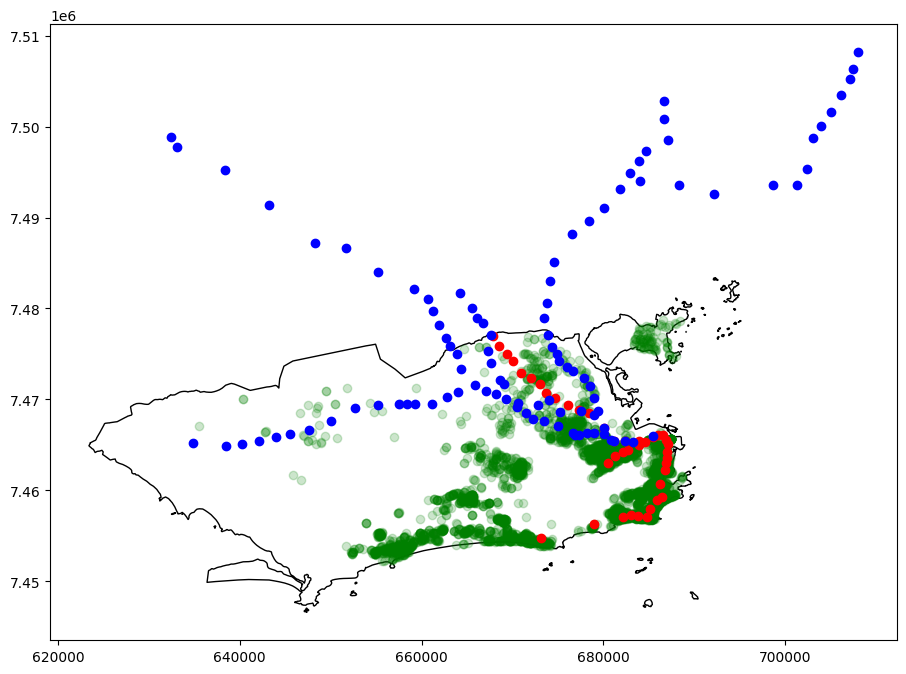

In [274]:
#Plotando os dados em um mapa
base = rj_rj_utm.plot(color='white', edgecolor='black', figsize=(15,8))
geo_dados_rj.plot(ax=base, color = 'green', figsize=(15,8), alpha=0.2)
metro.plot(ax=base, color = 'red', figsize=(15,8))
trens.plot(ax=base, color = 'blue', figsize=(15,8))

In [277]:
# Filtrando as estações de trens que ficam dentro do municipio do Rio de janeiro
trens = trens[trens.within(rj_rj_utm.iloc[0].geometry)]

<Axes: >

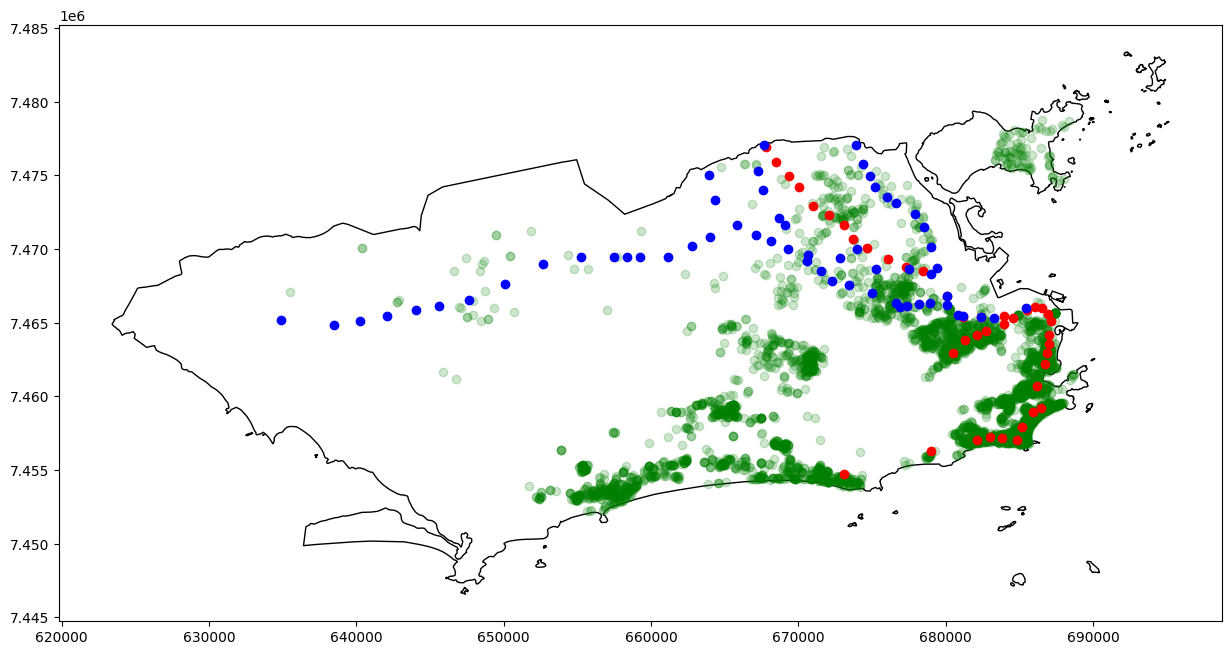

In [278]:
#Plotando os dados em um mapa
base = rj_rj_utm.plot(color='white', edgecolor='black', figsize=(15,8))
geo_dados_rj.plot(ax=base, color = 'green', figsize=(15,8), alpha=0.2)
metro.plot(ax=base, color = 'red', figsize=(15,8))
trens.plot(ax=base, color = 'blue', figsize=(15,8))

## Estações BRT

In [279]:
# Lendo os dados dos BRT

brt = gpd.read_file('Estações_BRT.geojson')
brt.head()

,OBJECTID,Nome,Flg_Ativo,Status,X,Y,Flg_TransCarioca,Flg_TransBrasil,Flg_TransOeste,Flg_TransOlimpica,ChaveGeo,Data_Inc,Integra_Trem,Integra_Metro,Integra_Aeroporto,geometry
0,1,Santa Luzia,1,1,679342.4694,7.471500e+06,1,0,0,0,None,None,0.0,0.0,0.0,POINT (-43.25244 -22.85513)
1,2,Maré,1,1,680236.1565,7.472380e+06,1,0,0,0,None,None,0.0,0.0,0.0,POINT (-43.24383 -22.84709)
2,3,Cardoso de Moraes - Viúva Garcia,1,1,678744.0560,7.471252e+06,1,0,0,0,None,None,0.0,0.0,0.0,POINT (-43.25824 -22.85743)
3,4,Penha I,1,1,676833.5642,7.473029e+06,1,0,0,0,None,None,0.0,0.0,0.0,POINT (-43.27706 -22.84158)
4,5,Penha II,1,1,676873.5062,7.472977e+06,1,0,0,0,None,None,0.0,0.0,0.0,POINT (-43.27666 -22.84205)


In [280]:
# Verificando CRS
brt.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [281]:
# Modificando o CRS
brt = brt.to_crs(epsg = 31983)

<Axes: >

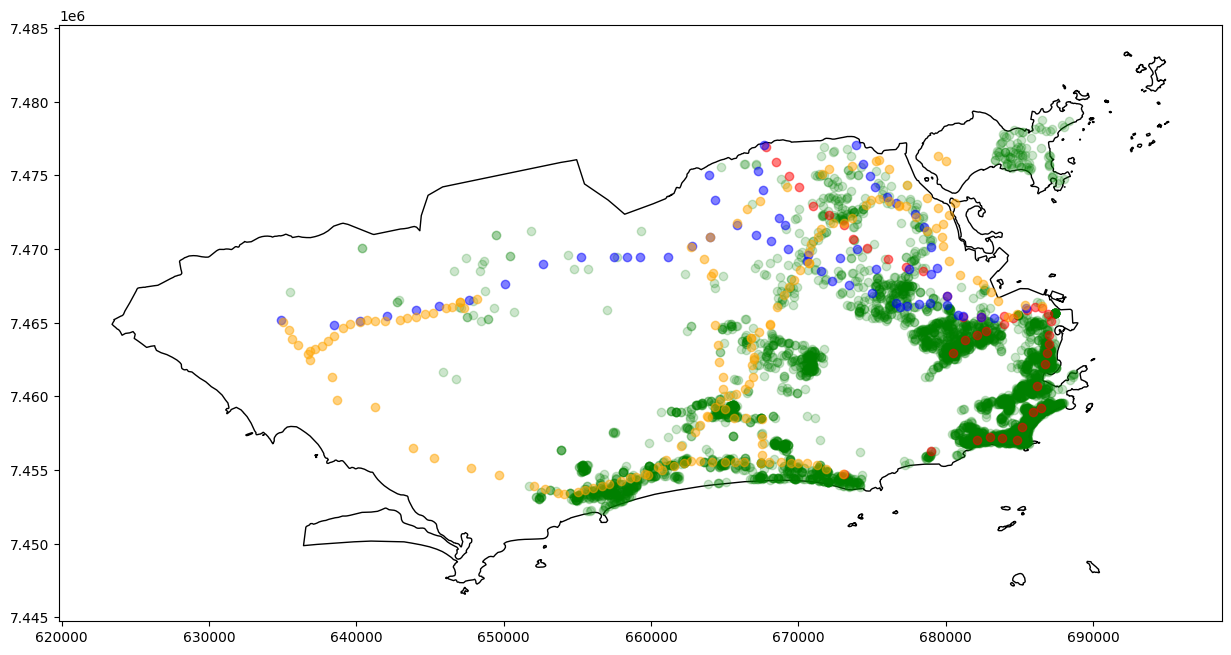

In [283]:
#Plotando os dados em um mapa
base = rj_rj_utm.plot(color='white', edgecolor='black', figsize=(15,8))
geo_dados_rj.plot(ax=base, color = 'green', figsize=(15,8), alpha=0.2)
metro.plot(ax=base, color = 'red', figsize=(15,8), alpha = 0.5)
trens.plot(ax=base, color = 'blue', figsize=(15,8), alpha = 0.5)
brt.plot(ax=base, color = 'orange', figsize=(15,8), alpha = 0.5)


In [284]:
#Concatenendo os dados das estações de transporte

transporte = pd.concat([trens.geometry, metro.geometry, brt.geometry], ignore_index = True)
transporte

,geometry
0,POINT (676865.998 7466079.221)
1,POINT (663963.689 7470815.165)
2,POINT (662791.766 7470217.933)
3,POINT (661118.717 7469485.408)
4,POINT (659274.333 7469468.712)
...,...
257,POINT (664056.38 7468206.813)
258,POINT (663575.572 7469329.639)
259,POINT (662677.42 7470133.15)
260,POINT (663982.622 7470796.25)


In [286]:
# Calculo das distâncias minimas
geo_dados_rj['Dist_Transporte'] = geo_dados_rj.geometry.apply(lambda x: (transporte.distance(x).min())/1000)
geo_dados_rj

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry,Dist_Metro,Dist_Transporte
0,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000,POINT (657513.707 7453832.425),15.622939,0.443193
1,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000,POINT (670523.903 7461803.088),7.530741,3.642787
2,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000,POINT (674345.004 7469439.743),0.736973,0.641470
3,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000,POINT (662701.378 7457284.071),10.718039,0.422370
5,260,Recreio dos Bandeirantes,Rio de Janeiro,Rua Desembargador Paulo Alonso,RJ,-23.018927,-43.477505,3,1,2,Apartamento,Venda,1160000,POINT (656018.715 7453574.299),17.131159,0.214605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,48,Campo Grande,Rio de Janeiro,Rua Josué de Barros,RJ,-22.878349,-43.550762,2,0,1,Apartamento,Venda,170000,POINT (648663.999 7469215.8),20.667831,2.129366
4996,75,Recreio dos Bandeirantes,Rio de Janeiro,Rua Le Corbusier,RJ,-23.024717,-43.487285,3,1,1,Apartamento,Venda,550000,POINT (655009.667 7452943.597),18.189134,0.563492
4997,32,Jardim Botânico,Rio de Janeiro,Rua Getúlio das Neves,RJ,-22.959433,-43.206180,1,0,0,Apartamento,Venda,580000,POINT (683909.38 7459847.754),2.180300,2.180300
4998,85,Grajaú,Rio de Janeiro,Rua Jerônimo de Lemos,RJ,-22.918773,-43.260492,3,0,0,Apartamento,Venda,325000,POINT (678393.129 7464417.213),2.558248,1.871081


## Calculando a distância até a praia




In [288]:
#Lendo os dados
cobertura = gpd.read_file('Cobertura_Vegetal_e_Uso_da_Terra_2016.geojson')
cobertura.head()

,Sigla,ANO,legenda,ShapeSTArea,ShapeSTLength,OBJECTID,GRUPO,CLASSE,FORMACOES,ESTAGIO_SUCESSIONAL,"SMAC""RIO\02497196""Mapeamento_CoberturaArea",geometry
0,Con,2016-01-01 00:00:00+00:00,Corpos d’água continentais,8684.890625,441.128326,19870,Outros,Corpos d’água continentais,,,8684.889153,"POLYGON ((-43.56601 -23.06277, -43.56611 -23.0..."
1,Con,2016-01-01 00:00:00+00:00,Corpos d’água continentais,2209.344727,241.436403,19871,Outros,Corpos d’água continentais,,,2209.343321,"POLYGON ((-43.59625 -23.04796, -43.59634 -23.0..."
2,Con,2016-01-01 00:00:00+00:00,Corpos d’água continentais,17015.344727,468.728882,19872,Outros,Corpos d’água continentais,,,17015.344086,"POLYGON ((-43.59737 -23.04845, -43.59754 -23.0..."
3,Con,2016-01-01 00:00:00+00:00,Corpos d’água continentais,17597.541016,916.463204,19873,Outros,Corpos d’água continentais,,,17597.540796,"POLYGON ((-43.60808 -23.04336, -43.60823 -23.0..."
4,Vg,2016-01-01 00:00:00+00:00,Vegetação gramíneo-lenhosa,11834.875977,605.329142,19874,Antropismo,Vegetação gramíneo-lenhosa,,,11834.876012,"POLYGON ((-43.56995 -23.05858, -43.57013 -23.0..."


In [289]:
# Verificando CRS
cobertura.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [290]:
#Modificando o CRS
cobertura = cobertura.to_crs(epsg = 31983)

In [291]:
#Valores unicos da coluna legenda
cobertura.legenda.unique()

array(['Corpos d’água continentais', 'Vegetação gramíneo-lenhosa',
       'Formação Pioneira com influência marinha, Dunas',
       'Vegetação arbórea não florestal', 'Áreas Urbanas', 'Praia',
       'Formação Pioneira com influência flúvio-marinha, Manguezal',
       'Formação Pioneira com influência flúvio-marinha, Campo Salino',
       'Formação Pioneira com influência marinha, Herbácea',
       'Formação Pioneira com influência marinha, Arbórea',
       'Formação Pioneira com influência marinha, Arbustiva',
       'Formação Pioneira com influência flúvio-lacustre, Brejo herbáceo',
       'Uso agrícola, Lavoura Permanente',
       'Floresta Ombrófila Densa, Estágio Inicial',
       'Floresta Ombrófila Densa, Estágio Médio', 'Afloramento Rochoso',
       'Uso agrícola, Lavoura Temporária', 'Solo exposto',
       'Reflorestamento', 'Floresta Ombrófila Densa, Estágio Avançado',
       'Atividades de Extração Mineral',
       'Formação Pioneira com influência flúvio-lacustre, Mata palud

In [292]:
# Filtrando as praias

praia = cobertura[cobertura['legenda'] == 'Praia']

<Axes: >

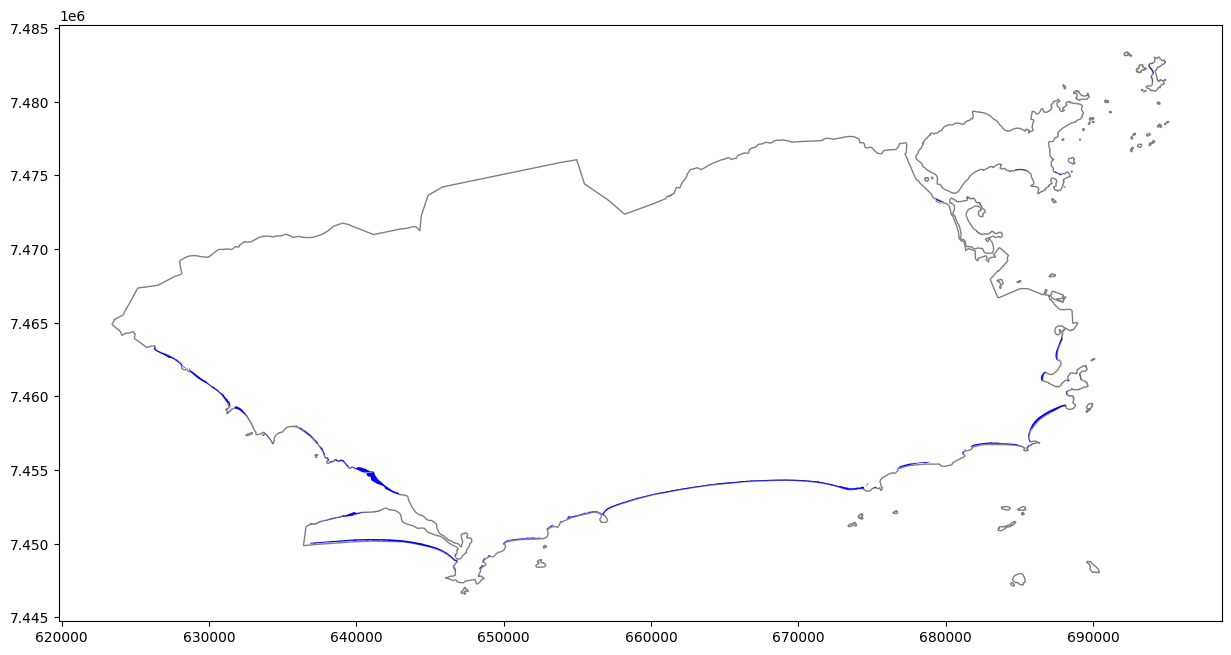

In [295]:
base = rj_rj_utm.plot(color='white', edgecolor='gray', figsize=(15,8))
praia.plot(ax = base, color = 'blue', figsize=(15,8))

In [298]:
geo_dados_rj['Dist_Praia'] = geo_dados_rj['geometry'].apply(lambda x: (praia.distance(x).min())/1000)
geo_dados_rj

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry,Dist_Metro,Dist_Transporte,Dist_Praia
0,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000,POINT (657513.707 7453832.425),15.622939,0.443193,1.143453
1,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000,POINT (670523.903 7461803.088),7.530741,3.642787,7.478698
2,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000,POINT (674345.004 7469439.743),0.736973,0.641470,6.240694
3,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000,POINT (662701.378 7457284.071),10.718039,0.422370,3.404589
5,260,Recreio dos Bandeirantes,Rio de Janeiro,Rua Desembargador Paulo Alonso,RJ,-23.018927,-43.477505,3,1,2,Apartamento,Venda,1160000,POINT (656018.715 7453574.299),17.131159,0.214605,1.369015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,48,Campo Grande,Rio de Janeiro,Rua Josué de Barros,RJ,-22.878349,-43.550762,2,0,1,Apartamento,Venda,170000,POINT (648663.999 7469215.8),20.667831,2.129366,16.133493
4996,75,Recreio dos Bandeirantes,Rio de Janeiro,Rua Le Corbusier,RJ,-23.024717,-43.487285,3,1,1,Apartamento,Venda,550000,POINT (655009.667 7452943.597),18.189134,0.563492,0.955964
4997,32,Jardim Botânico,Rio de Janeiro,Rua Getúlio das Neves,RJ,-22.959433,-43.206180,1,0,0,Apartamento,Venda,580000,POINT (683909.38 7459847.754),2.180300,2.180300,2.612550
4998,85,Grajaú,Rio de Janeiro,Rua Jerônimo de Lemos,RJ,-22.918773,-43.260492,3,0,0,Apartamento,Venda,325000,POINT (678393.129 7464417.213),2.558248,1.871081,7.679812


In [299]:
geo_dados_rj.to_file('DATASET.shp')

/tmp/ipython-input-253219552.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  geo_dados_rj.to_file('DATASET.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Dist_Transporte' to 'Dist_Trans'
  ogr_write(
